In [ ]:
# --- repo path setup (added during reorg) ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))


In [2]:
import numpy as np

def find_zero_crossings(x, d2A, tol=1e-8):

    # 1) copy and threshold small values to zero
    d2 = np.asarray(d2A, dtype=float).copy()
    d2[np.abs(d2) < tol] = 0.0

    # 2) compute sign array and fill any zeros by neighbor signs
    signs = np.sign(d2)
    zero_locs = np.where(signs == 0)[0]
    for z in zero_locs:
        if z + 1 < len(signs):
            signs[z] = signs[z+1]
        else:
            signs[z] = signs[z-1]

    # 3) find raw sign‐change indices
    cross_idxs = np.where(signs[:-1] * signs[1:] < 0)[0]

    # 4) linearly interpolate the crossing points
    x_crossings = []
    for i in cross_idxs:
        x0, x1 = x[i], x[i+1]
        y0, y1 = d2A[i],  d2A[i+1]
        if y1 != y0:
            xc = x0 - y0 * (x1 - x0) / (y1 - y0)
        else:
            xc = 0.5*(x0 + x1)
        x_crossings.append(xc)

    return cross_idxs, x_crossings

def residual_free_energy_multi_numba(phi, β, z,g,
                                     patch_to_species, ε_patch, m_patch,eps_ns=0):
    # 1) Ideal mixing
    A_mix = 0.0
    for i in range(phi.shape[0]):
        A_mix += phi[i]*np.log(phi[i]/g[i]) # + (1-phi[i])*np.log(1-phi[i])
    # 2) Association
    X = solve_association_multi_numba(phi, patch_to_species,ε_patch, m_patch, β, z)
    A_assoc = 0.0
    P = m_patch.shape[0]
    for p in range(P):
        s = patch_to_species[p]
        A_assoc += m_patch[p]* phi[s]  * (np.log(X[p]) - 0.5*X[p] + 0.5)
    return (A_mix+ A_assoc ),A_mix

def solve_association_multi_numba(phi, patch_to_species, eps_patch, m_patch, beta, z,
                                  tol=1e-8, max_iter=5000, alpha=0.2):
    P = eps_patch.shape[0]
    Delta = (np.exp(beta * eps_patch) - 1.0) / z  # keep your 1/4 if that is your lattice normalization
    phi_p = phi[patch_to_species]

    X = np.ones(P)
    X_new = np.empty(P)
    denom = np.empty(P)

    for _ in range(max_iter):
        # build denom
        for j in range(P):
            tmp = 0.0
            for k in range(P):
                tmp += Delta[j, k] * phi_p[k] * X[k] * m_patch[k]
            val = 1.0 + tmp                 # <-- use z
            if val <= 1e-16:                    # if this triggers often, your model/inputs are problematic
                val = 1e-16
            denom[j] = val

        # fixed-point map
        for j in range(P):
            Xfp = 1.0 / denom[j]
            Xn  = alpha * Xfp + (1.0 - alpha) * X[j]
            # clip (fine), but don’t let this mask persistent denom pathologies
            if Xn < 1e-16: Xn = 1e-16
            if Xn > 1.0:   Xn = 1.0
            X_new[j] = Xn

        maxdiff = np.max(np.abs(X_new - X))
        if not np.isfinite(maxdiff):
            return X  # or raise

        if maxdiff < tol:
            return X_new.copy()

        X[:] = X_new

    return X


In [2]:
eps_as=np.linspace(0,10,21)
eps_cs=np.linspace(0,2.5,21)
import matplotlib.pyplot as plt

z=4
spinodal2_2d=np.zeros((len(eps_as),len(eps_cs)))


for j,eps_c in enumerate(eps_cs):     
    for i,eps_a in enumerate(eps_as):
        print(eps_c,eps_a)
        J=np.zeros((3,3))
        J[0,0]=eps_a; J[:-1,:-1] += eps_c 
        patch_to_species=np.array([0,0,1])
        m_patch=np.array([2,2,4])    
        g=[1,1]
        A= lambda phi: residual_free_energy_multi_numba(np.array([phi,1-phi]), 1, z,g,
                                                        patch_to_species,J, m_patch,eps_ns=eps_c)
        X= lambda phi: solve_association_multi_numba(np.array([phi,1-phi]), patch_to_species, J, m_patch, 
                                                     1, z)
        phis_grid=np.linspace(0.01,0.99,151)
        free=[A(np.array(phi))[0] for phi in phis_grid]
        entropy=[A(np.array(phi))[1] for phi in phis_grid]
        unb_frac=[X(phi)[0] for phi in phis_grid]
        
        
        dfree = np.gradient(free,phis_grid)
        ddfree = np.gradient(dfree,phis_grid)

        eq=ddfree
        cross_idxs, x_crossings=find_zero_crossings(phis_grid,eq)
        #plt.plot(phis_grid,eq)
        #plt.show()
        if len(cross_idxs)>=2:

            spinodal2_2d[i,j]=1
            #plt.plot(phis_grid,eq)
            #plt.title(f'eps_a {eps_a:.4f} eps_c {eps_c:.4f}')
            #plt.ylim([-2,2])
            #plt.show()
            #plt.plot(phis_grid,np.gradient(np.gradient(entropy,phis_grid),phis_grid))
            #plt.show()
            break


0.0 0.0
0.0 0.5
0.0 1.0
0.0 1.5
0.0 2.0
0.0 2.5
0.0 3.0
0.0 3.5
0.0 4.0
0.0 4.5
0.0 5.0
0.0 5.5
0.0 6.0
0.0 6.5
0.0 7.0
0.0 7.5
0.0 8.0
0.0 8.5
0.0 9.0
0.0 9.5
0.0 10.0
0.125 0.0
0.125 0.5
0.125 1.0
0.125 1.5
0.125 2.0
0.125 2.5
0.125 3.0
0.125 3.5
0.125 4.0
0.125 4.5
0.125 5.0
0.125 5.5
0.125 6.0
0.125 6.5
0.125 7.0
0.125 7.5
0.125 8.0
0.125 8.5
0.125 9.0
0.125 9.5
0.125 10.0
0.25 0.0
0.25 0.5
0.25 1.0
0.25 1.5
0.25 2.0
0.25 2.5
0.25 3.0
0.25 3.5
0.25 4.0
0.25 4.5
0.25 5.0
0.25 5.5
0.25 6.0
0.25 6.5
0.25 7.0
0.25 7.5
0.25 8.0
0.25 8.5
0.25 9.0
0.25 9.5
0.25 10.0
0.375 0.0
0.375 0.5
0.375 1.0
0.375 1.5
0.375 2.0
0.375 2.5
0.375 3.0
0.375 3.5
0.375 4.0
0.375 4.5
0.375 5.0
0.375 5.5
0.375 6.0
0.375 6.5
0.375 7.0
0.375 7.5
0.375 8.0
0.375 8.5
0.375 9.0
0.375 9.5
0.375 10.0
0.5 0.0
0.5 0.5
0.5 1.0
0.5 1.5
0.5 2.0
0.5 2.5
0.5 3.0
0.5 3.5
0.5 4.0
0.5 4.5
0.5 5.0
0.5 5.5
0.5 6.0
0.5 6.5
0.5 7.0
0.5 7.5
0.5 8.0
0.5 8.5
0.5 9.0
0.5 9.5
0.5 10.0
0.625 0.0
0.625 0.5
0.625 1.0
0.625 1.5
0.625 2.0


In [13]:
import json
with open("../data/spinodal_du_saft.json","w") as f:
    json.dump(spinodal3_hex.tolist(), f)

In [12]:
eps_as=np.linspace(0,8,21)
eps_cs=np.linspace(0,1.5,31)
import matplotlib.pyplot as plt
z=6
spinodal3_hex=np.zeros((len(eps_as),len(eps_cs)))


for j,eps_c in enumerate(eps_cs):     
    for i,eps_a in enumerate(eps_as):
        print(eps_c,eps_a)
        J=np.zeros((3,3))
        J[0,0]=eps_a; J[:-1,:-1] += eps_c 
        patch_to_species=np.array([0,0,1])
        m_patch=np.array([2,4,6])    
        g=[1,1]
        A= lambda phi: residual_free_energy_multi_numba(np.array([phi,1-phi]), 1, z,g,
                                                        patch_to_species,J, m_patch,eps_ns=eps_c)
        X= lambda phi: solve_association_multi_numba(np.array([phi,1-phi]), patch_to_species, J, m_patch, 
                                                     1, z)
        phis_grid=np.linspace(0.01,0.99,151)
        free=[A(np.array(phi))[0] for phi in phis_grid]
        entropy=[A(np.array(phi))[1] for phi in phis_grid]
        unb_frac=[X(phi)[0] for phi in phis_grid]
        
        
        dfree = np.gradient(free,phis_grid)
        ddfree = np.gradient(dfree,phis_grid)

        eq=ddfree
        cross_idxs, x_crossings=find_zero_crossings(phis_grid,eq)
        #plt.plot(phis_grid,eq)
        #plt.show()
        if len(cross_idxs)>=2:

            spinodal3_hex[i,j]=1
            #plt.plot(phis_grid,eq)
            #plt.title(f'eps_a {eps_a:.4f} eps_c {eps_c:.4f}')
            #plt.ylim([-2,2])
            #plt.show()
            #plt.plot(phis_grid,np.gradient(np.gradient(entropy,phis_grid),phis_grid))
            #plt.show()
            break


0.0 0.0
0.0 0.4
0.0 0.8
0.0 1.2000000000000002
0.0 1.6
0.0 2.0
0.0 2.4000000000000004
0.0 2.8000000000000003
0.0 3.2
0.0 3.6
0.0 4.0
0.0 4.4
0.0 4.800000000000001
0.0 5.2
0.0 5.6000000000000005
0.0 6.0
0.0 6.4
0.0 6.800000000000001
0.0 7.2
0.0 7.6000000000000005
0.0 8.0
0.05 0.0
0.05 0.4
0.05 0.8
0.05 1.2000000000000002
0.05 1.6
0.05 2.0
0.05 2.4000000000000004
0.05 2.8000000000000003
0.05 3.2
0.05 3.6
0.05 4.0
0.05 4.4
0.05 4.800000000000001
0.05 5.2
0.05 5.6000000000000005
0.05 6.0
0.05 6.4
0.05 6.800000000000001
0.05 7.2
0.05 7.6000000000000005
0.05 8.0
0.1 0.0
0.1 0.4
0.1 0.8
0.1 1.2000000000000002
0.1 1.6
0.1 2.0
0.1 2.4000000000000004
0.1 2.8000000000000003
0.1 3.2
0.1 3.6
0.1 4.0
0.1 4.4
0.1 4.800000000000001
0.1 5.2
0.1 5.6000000000000005
0.1 6.0
0.1 6.4
0.1 6.800000000000001
0.1 7.2
0.1 7.6000000000000005
0.1 8.0
0.15000000000000002 0.0
0.15000000000000002 0.4
0.15000000000000002 0.8
0.15000000000000002 1.2000000000000002
0.15000000000000002 1.6
0.15000000000000002 2.0
0.15000

In [4]:

eps_c_spinodal2_m=[]
eps_a_spinodal2_m=[]
for j in range(len(eps_cs)):
    if len(np.where(spinodal3_hex[:,j])[0])>0 and eps_cs[j]<=2.3:
        eps_a_spinodal2_m.append(eps_as[np.min(np.where(spinodal3_hex[:,j]==1)[0])])
        eps_c_spinodal2_m.append(eps_cs[j])


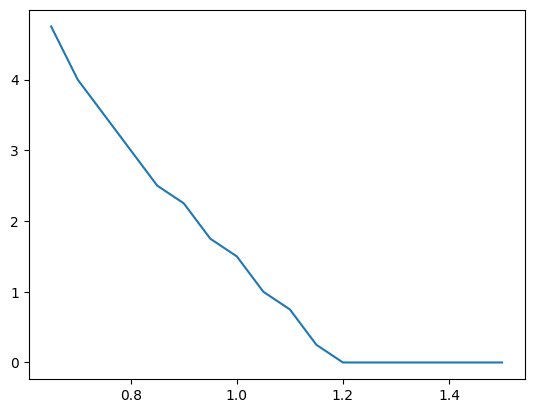

In [5]:
plt.plot(eps_c_spinodal2_m,eps_a_spinodal2_m)